# Overview

- Keeps only insect boxes intersecting or within the ROI (target/main flower).
- Defines cropping regions based on the union of insect boxes and ROI box coordinates
- Adjusts the original full frame insect box coordinates to fit with the cropped image.

This notebook requires the `general` environment (kernel). See ./envs/README.md for more information.

In [3]:
import os
import pandas as pd
import simplejson
import time
import cv2
import git
import sys
import logging
import matplotlib.pyplot as plt
from PIL import Image
import multiprocessing as mp
import dask.dataframe as dd
from dask.distributed import Client
from functools import partial

# Get the root path of the project using Git and print it for verification
prj_path = git.Repo('.', search_parent_directories=True).working_tree_dir
print(f"Root path of the project:\n'{prj_path}'")

# Add the path to the directory containing utils.py to sys.path
sys.path.append(f"{prj_path}/code")

# Import needed function from utils.py
from utils import *

# Set up logging
logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)

Root path of the project:
'/scratch/vs66tavy/smartphone-insect-detect'


# Read and prepare data

In [4]:
# Read the annotation dataset (for full frame images)
file_path = os.path.join(prj_path, 'data', 'annotations', 'annotations_full_frames.feather')
df = pd.read_feather(file_path)

# Construct image paths and add them to the dataframe
full_frame_dir_path = os.path.join(prj_path, 'data', 'images', 'raw')
df['path'] = df['filename_full_frame'].apply(lambda x: os.path.join(full_frame_dir_path, x))

# Drop images that contain no_id and thysanoptera cases (in the order variable).
# Get all the paths where order = thysanoptera or no_id
mask = df["order"].isin(["thysanoptera", "no_id"])
paths_to_drop = df[mask]["path"].unique()
# Drop those paths
df = df[~df["path"].isin(paths_to_drop)]

# Are there any images without ROI? Expect 0.
print(f"Rows without ROI: {df['x_roi'].isna().sum()}" )

Rows without ROI: 0


# Keep only insect boxes intersecting the ROI

First keep only the insect boxes that intersect with the ROI

Then remove remaining sequences within the ROI where all insects are just 'background' insects.
This means, retain all images in a sequence associate with an individual insect if at least one insect is marked to be kept. So, if an insect at some point flying or moving trough the ROI decided to visit the target flower (within the ROI), it was market at that moment to be kept, so the entire frames associated with that individual insect are kept.

182 boxes are of individual insects that are within the ROI, but not on the target flower (often they are under the target flower, on a background flower of plant part). These will be removed from final evaluation.

In [5]:
# Discard any box that is not intersecting or included in the ROI. 
# The function apply_iou_roi() was imported from utils.py
df['iou_w_roi'] = df.apply(apply_iou_roi, axis=1)
df = df[df['iou_w_roi'] > 0]

# Remove remaining sequences within the ROI where all insects are just
# 'background' insects. Keep the sequence if any 'keep_seq' value is True for
# that path. 
df = df.groupby('path').filter(lambda group: group['keep_seq'].any())
df = df.reset_index(drop=True)

print(f"Number of boxes after filtering: {df.shape[0]}")

# 182 boxes are of individual insects that are within the ROI, but not on the
# target flower
print( df['keep_seq'].value_counts() )

Number of boxes after filtering: 24838
keep_seq
True     24656
False      182
Name: count, dtype: int64


# Prepare cropping regions

In [6]:
# For PIL compatibility, truncate the float values to the smallest integer
cols = ['x', 'y', 'width', 'height', 
        'x_roi', 'y_roi', 'width_roi', 'height_roi']
for col in cols:
    df[col] = df[col].astype(int)

In [7]:
# Check if box coordinates are within expected values
print(f"x min: {df['x'].min()}, x max: {df['x'].max()}")
print(f"y min: {df['y'].min()}, y max: {df['y'].max()}")
print(f"width min: {df['width'].min()}, width max: {df['width'].max()}")
print(f"height min: {df['height'].min()}, height max: {df['height'].max()}")
print(f"x min ROI: {df['x_roi'].min()}, x max ROI: {df['x_roi'].max()}")
print(f"y min ROI: {df['y_roi'].min()}, y max ROI: {df['y_roi'].max()}")
print(f"width min ROI: {df['width_roi'].min()}, width max ROI: {df['width_roi'].max()}")
print(f"height min ROI: {df['height_roi'].min()}, height max ROI: {df['height_roi'].max()}")

x min: 0, x max: 1796
y min: 0, y max: 1317
width min: 19, width max: 995
height min: 21, height max: 935
x min ROI: 4, x max ROI: 1168
y min ROI: 4, y max ROI: 773
width min ROI: 292, width max ROI: 1820
height min ROI: 200, height max ROI: 1423


In [8]:
# Compute coordinates for the cropping boxes.
# Each crop box is the union of all insect boxes and the ROI box, encompassing them entirely.

# Start timing
start_time = time.time()

# Calculate the number of workers (total cores minus 1)
n_workers = max(1, mp.cpu_count() - 1)  # Ensure at least one CPU is used
print(f"Using {n_workers} workers")
# Set up Dask client with the calculated number of workers
client = Client(n_workers=n_workers)
print(f"Dask client: {client}")
# Convert the DataFrame to a Dask DataFrame
ddf = dd.from_pandas(df, npartitions=n_workers)
# Specify the structure and data types of the output for the meta parameter.
meta_dict = {'x': 'int64', 
             'y': 'int64', 
             'width': 'int64', 
             'height': 'int64',
             'new_filename': 'object'}
# Group by 'path' and apply calculate_bounding_box_crop() imported from utils.py
meta = pd.DataFrame(columns=meta_dict.keys(), dtype=object)
meta = meta.astype(meta_dict)
ddf_crops = ddf.groupby('path').apply(
    calculate_bounding_box_crop,
    dtype_dict=meta_dict,
    meta=meta
    )
# Prepare results; Move the 'path' index used for grouping to a column.
df_crops = ddf_crops.compute().reset_index()
# Remove the `level_1` index column created by Dask
df_crops.drop(columns=['level_1'], inplace=True)

# End timing
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds ({(end_time - start_time)/60:.2f} minutes)")
# Close the Dask client
client.close()

Using 15 workers


/scratch/vs66tavy/smartphone-insect-detect/envs/general/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41755 instead
  warnings.warn(


Dask client: <Client: 'tcp://127.0.0.1:38495' processes=15 threads=30, memory=62.66 GiB>


/scratch/vs66tavy/smartphone-insect-detect/envs/general/lib/python3.10/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 14.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-03-28 14:41:51,438 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 6e17c8265549e4de00d899b82152ee95 initialized by task ('shuffle-transfer-6e17c8265549e4de00d899b82152ee95', 6) executed on worker tcp://127.0.0.1:44977
2025-03-28 14:41:52,679 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 6e17c8265549e4de00d899b82152ee95 deactivated due to stimulus 'task-finished-1743169312.6747146'


Time taken: 13.54 seconds (0.23 minutes)


In [9]:
# Note that here, 'x', 'y', 'width', 'height' are the coordinates of the crop box.
print(df_crops.columns)
print(df_crops.shape)

Index(['path', 'x', 'y', 'width', 'height', 'new_filename'], dtype='object')
(23899, 6)


In [10]:
df_crops.sample(5, random_state=42)

,path,x,y,width,height,new_filename
7481,/scratch/vs66tavy/smartphone-insect-detect/dat...,124,6,1067,920,img_crop_14944.jpg
11127,/scratch/vs66tavy/smartphone-insect-detect/dat...,498,6,1087,706,img_crop_22354.jpg
7932,/scratch/vs66tavy/smartphone-insect-detect/dat...,498,6,1087,706,img_crop_21908.jpg
22072,/scratch/vs66tavy/smartphone-insect-detect/dat...,158,318,988,874,img_crop_20778.jpg
18147,/scratch/vs66tavy/smartphone-insect-detect/dat...,461,367,574,521,img_crop_10132.jpg


In [11]:
# Expect that the returned crop coordinates to be integers
print(f"x type: {df_crops['x'].dtype}, y type: {df_crops['y'].dtype}")
print(f"width type: {df_crops['width'].dtype}, height type: {df_crops['height'].dtype}")

x type: int64, y type: int64
width type: int64, height type: int64


In [12]:
# Read the image width and height and orientation for each raw/full-frame/uncropped image.
# I needed to read each file individually because sometimes within the same plant folder
# there are images with different orientations. 
# This most probably happened because the phone was readjusted and rotated on the 
# tripod holder during time-lapse capture.

# Note that the speed of this operation depends a lot on the I/O speed of your SSD or 
# HDD or if you store the images over a network share.
# Also, using too many CPUs for a slow I/O storage unit can slow down the unit or even lead to a crash.
# Serial operation (on one core and network share) took ~ 30 minutes.

# Set up multiprocessing with a Dask client
n_workers = max(1, mp.cpu_count() - 1)  # Ensure at least one CPU is used
print(f"Using {n_workers} workers")
client = Client(n_workers=n_workers)
print(f"Dask client: {client}")

start_time = time.time()

# Convert the DataFrame to a Dask DataFrame
# The number of partitions is set to be equal to the number of workers
ddf = dd.from_pandas(df_crops, npartitions=n_workers)
# Apply the function get_image_dim() to the Dask DataFrame. 
# get_image_dim() was imported from utils.py
results_ddf = ddf.apply(
    get_image_dim, 
    axis=1, 
    args=('path',),  # Pass 'path' as the path_col_name argument
    meta={'path': 'string', 
          'img_width_pil': 'float64', 
          'img_height_pil': 'float64', 
          'img_orientation': 'float64'}
).compute()

end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds ({(end_time - start_time)/60:.2f} minutes) on {n_workers} CPUs.")
# Close the Dask client
client.close()

Using 15 workers


/scratch/vs66tavy/smartphone-insect-detect/envs/general/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45743 instead
  warnings.warn(


Dask client: <Client: 'tcp://127.0.0.1:42969' processes=15 threads=30, memory=62.66 GiB>
Time taken: 3.56 seconds (0.06 minutes) on 15 CPUs.


In [13]:
# Merge the results from above with the original df_crops DataFrame
df_crops = df_crops.merge(results_ddf, on='path', how='left')

In [14]:
# Check the unique values of the image dimensions and orientation (for full frames)
cols = ['img_width_pil', 'img_height_pil', 'img_orientation']
for col in cols:
    print(f"{col}: {sorted(df_crops[col].unique())}")

img_width_pil: [np.int64(1152), np.int64(1200), np.int64(1280), np.int64(1600), np.int64(2048), np.int64(2400)]
img_height_pil: [np.int64(720), np.int64(864), np.int64(1200), np.int64(1536), np.int64(1600)]
img_orientation: [np.int64(0), np.int64(1), np.int64(3), np.int64(6), np.int64(8)]


In [15]:
df_crops.sample(5, random_state=42)

,path,x,y,width,height,new_filename,img_width_pil,img_height_pil,img_orientation
7481,/scratch/vs66tavy/smartphone-insect-detect/dat...,124,6,1067,920,img_crop_14944.jpg,1600,1200,6
11127,/scratch/vs66tavy/smartphone-insect-detect/dat...,498,6,1087,706,img_crop_22354.jpg,1600,1200,3
7932,/scratch/vs66tavy/smartphone-insect-detect/dat...,498,6,1087,706,img_crop_21908.jpg,1600,1200,3
22072,/scratch/vs66tavy/smartphone-insect-detect/dat...,158,318,988,874,img_crop_20778.jpg,1600,1200,1
18147,/scratch/vs66tavy/smartphone-insect-detect/dat...,461,367,574,521,img_crop_10132.jpg,1600,1200,1


In [16]:
# Check if the cropping boxes are within the image dimensions
df_crops[['width_out_of_bounds', 'height_out_of_bounds']] = df_crops.apply(check_out_of_bounds, axis=1)

# Rows where width_out_of_bounds or height_out_of_bounds is True.
# They indicate that orientation needs to be accounted for.
mask = (df_crops['width_out_of_bounds'] == True) | (df_crops['height_out_of_bounds'] == True)
print( df_crops[mask].shape[0] )

# Sum up df_crops['y'] + df_crops['height'] and compute the difference from df_crops['img_height_pil']
df_crops['test_y_height'] = df_crops['y'] + df_crops['height'] - df_crops['img_height_pil']

# What are the orientation values for the rows where width_out_of_bounds or height_out_of_bounds
# is True?
df_crops[mask]['img_orientation'].value_counts()
# The orientation = 1 cases are due to 1 pixel rounding error.

803


img_orientation
8    457
6    338
1      8
Name: count, dtype: int64

In [17]:
# For the orientation = 6 or 8, the width and height need to be swapped.
mask = (df_crops['img_orientation'] == 6) | (df_crops['img_orientation'] == 8)
df_crops.loc[mask, ['img_width_pil', 'img_height_pil']] = df_crops.loc[mask, ['img_height_pil', 'img_width_pil']].values

In [18]:
# Check again if there are any rows where width_out_of_bounds or height_out_of_bounds is True.
df_crops[['width_out_of_bounds', 'height_out_of_bounds']] = df_crops.apply(check_out_of_bounds, axis=1)
mask = (df_crops['width_out_of_bounds'] == True) | (df_crops['height_out_of_bounds'] == True)
print( df_crops[mask].shape[0] )

# The remaining 8 cases are due to 1 pixel rounding error.
# For these cases, reduce the height by 1 pixel to be on the safe side with the cropping.
# This is because y + height goes 1 pixel more than the image height.
df_crops.loc[mask, 'height'] = df_crops.loc[mask, 'height'] - 1

8


In [19]:
# Expect 0 cases now
df_crops[['width_out_of_bounds', 'height_out_of_bounds']] = df_crops.apply(check_out_of_bounds, axis=1)
mask = (df_crops['width_out_of_bounds'] == True) | (df_crops['height_out_of_bounds'] == True)
print( df_crops[mask].shape[0] )

0


In [20]:
# Since all values in  width_out_of_bounds & height_out_of_bounds are False, drop these columns
cols = ['width_out_of_bounds', 'height_out_of_bounds']
for col in cols:
    print(f"{col}: {sorted(df_crops[col].unique())}")

df_crops = df_crops.drop(columns=cols)

# Drop also the helper column 'test_y_height'
df_crops = df_crops.drop(columns=['test_y_height'])

width_out_of_bounds: [np.False_]
height_out_of_bounds: [np.False_]


# Adjust insect bbox coord

When cropping we also need to adjust the new bbx coordinates of the insects.

In [21]:
common_columns = sorted(set(df_crops.columns).intersection(df.columns))
print(common_columns)

['height', 'new_filename', 'path', 'width', 'x', 'y']


In [22]:
# Set a temporary data frame for merging so that df_crops keeps the original
# columns (df_crops will be save to disk for full frame image cropping in a next
# step)
df_temp = df_crops.copy()
# Drop the 'new_filename' column from the copied DataFrame in place to avoid
# duplication with the same column in df when creating df_roi below
df_temp.drop('new_filename', axis=1, inplace=True)

# Rename x, y, width, height to x_crop, y_crop, width_crop, height_crop
df_temp = df_temp.rename(columns={'x': 'x_crop', 
                                  'y': 'y_crop', 
                                  'width': 'width_crop', 
                                  'height': 'height_crop'})

df_roi = pd.merge(df, df_temp, on='path', how='left').copy()

In [23]:
# Update insect bbox coordinates

# Keep a copy of the original insect box coordinates
df_roi['x_orig'] = df_roi['x']
df_roi['y_orig'] = df_roi['y']
df_roi['width_orig'] = df_roi['width']
df_roi['height_orig'] = df_roi['height']

# adjust_coordinates() was imported from utils.py
df_roi = df_roi.apply(adjust_coordinates, axis=1)

In [24]:
# Check if there are any negative values in x or y - expect none
df_roi.loc[(df_roi['x'] < 0) | (df_roi['y'] < 0), ['new_filename', 'x', 'y']].shape[0]

0

Note that when cropping insect boxes, the boxes of insects within the ROI but not on the target flower where kept. Some that are partially outside the ROI end up being cropped. This will not be considered as False Positives but they are highly unlikely to be detected anyways by the models. Below is a visual example.

In [25]:
# Filter for those rows where keep_seq = False, subset to the columns of interest:
# path, n_boxes, order. This is to help with visually inspecting some cases below.
df_keep_false = df_roi.loc[df_roi['keep_seq'] == False, ['path', 'n_boxes', 'order']]
df_keep_false.shape
# There are 182 such cases.

(182, 3)

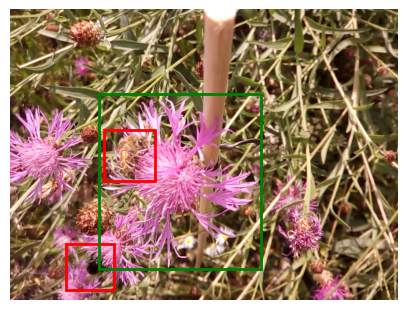

In [26]:
# Visual example of the full frame with two insects and the cropping box
# The function visualize_image() below was imported from utils.py
my_filename_full_frame = "2021-07-19_centaurea-sp-01-EC_IMG_20210719_120105.jpg"
# Find the row in df where 'filename_full_frame' matches my_filename_full_frame
matching_row = df[df['filename_full_frame'] == my_filename_full_frame].iloc[0]
# Extract my_img_path from the matching row
my_img_path = matching_row['path']
visualize_image(df, my_img_path, crop=False, show_crop_bbx=False, show_roi=True)
# ROI box with green color, insect boxes with red color

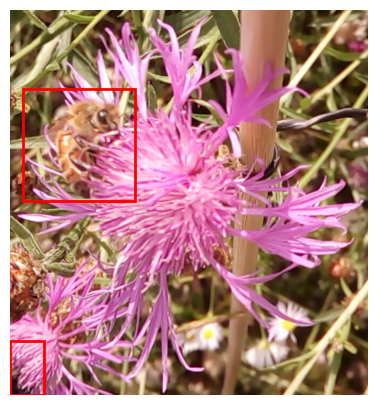

In [27]:
# This is how it looks after cropping. The cropping is done "on the fly" here
# by the visualize_image function.
visualize_image(df_roi, my_img_path, crop=True, show_crop_bbx=False, show_roi=False)
# The crop bbx and ROI coordinates are not being updated during display, so were set to False.

# Save the updated annotations

In [28]:
# Also, reconstruct the labels used in the previous study when the YOLO models were trained.
# p1_labels represents the training labels.
def create_p1_labels(row):
    order = row['order']
    family = row['family']

    if order == 'hymenoptera' and family == 'formicidae':
        return 'hymenoptera_f'
    else:
        return order
    
df_roi['p1_labels'] = df_roi.apply(create_p1_labels, axis=1)

In [29]:
df.shape

(24838, 41)

In [30]:
# Export to Feather file
file_path = os.path.join(prj_path, 'data', 'processed', 'df_roi.feather')
df_roi.to_feather(file_path)

# Export also as a tab-separated txt file without surrounding quotes
file_path_txt = os.path.join(prj_path, 'data', 'processed', 'df_roi.txt')
df_roi.to_csv(file_path_txt, sep='\t', index=False, quoting=3)

# Save also the intermediary df_crops - needed for cropping the full frame images in a next step.
file_path = os.path.join(prj_path, 'data', 'processed', 'df_crops_interim.feather')
df_crops.to_feather(file_path)